# Synthetic VibeTags Data — EDA
Exploratory analysis of the naive model output: how faithfully does the simulated VibeTags signal
represent the true sequence, and where does it fail?

In [1]:
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from vibeseq.simulation import load_confusion_matrix

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
sns.set_style("whitegrid")

H5_PATH  = Path.cwd().parent / "data" / "synthetic" / "naive_n1000_seed42.h5"
CM_PATH  = Path.cwd().parent / "assets" / "rf_cm.npy"

classes, cm_frac = load_confusion_matrix(CM_PATH)
AA = classes          # list of 20 AA single-letter codes
N_AA = len(AA)
aa_to_idx = {a: i for i, a in enumerate(AA)}

In [2]:
sequences, outputs = [], []

with h5py.File(H5_PATH, "r") as f:
    protein_ids = list(f.keys())
    for pid in protein_ids:
        sequences.append(f[pid]["sequence"][()].decode())
        outputs.append(f[pid]["vibeTag_output"][()])

lengths = np.array([len(s) for s in sequences])
print(f"Proteins loaded : {len(sequences):,}")
print(f"Total residues  : {lengths.sum():,}")
print(f"Length — min {lengths.min()}, median {int(np.median(lengths))}, max {lengths.max()}")

Proteins loaded : 1,000
Total residues  : 551,521
Length — min 15, median 421, max 5202


## 1. Protein Length Distribution

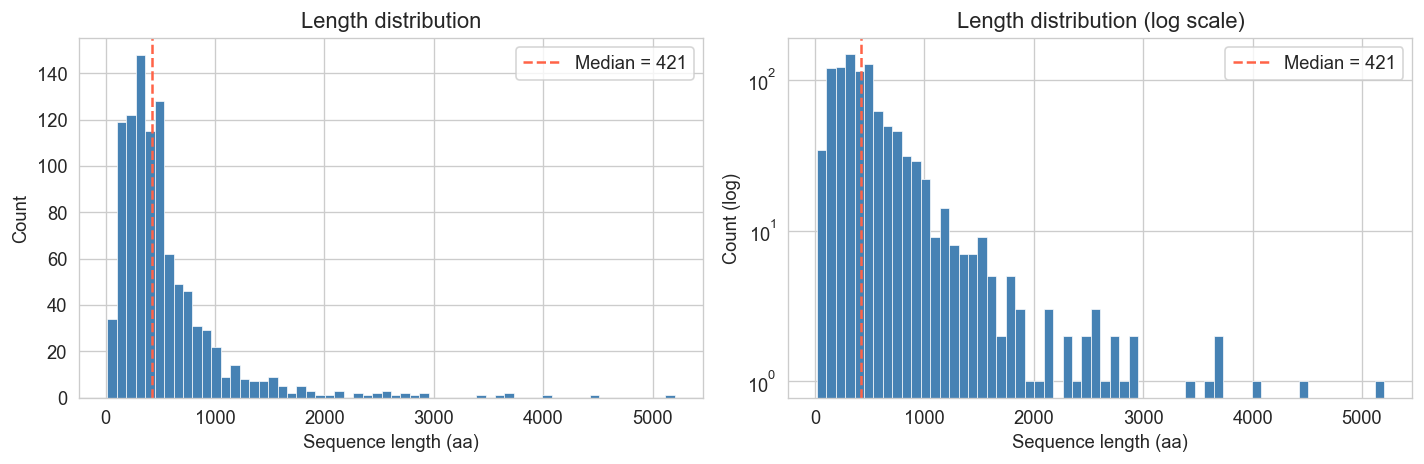

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lengths, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set(xlabel="Sequence length (aa)", ylabel="Count", title="Length distribution")

axes[1].hist(lengths, bins=60, color="steelblue", edgecolor="white", linewidth=0.4, log=True)
axes[1].set(xlabel="Sequence length (aa)", ylabel="Count (log)", title="Length distribution (log scale)")

for ax in axes:
    ax.axvline(np.median(lengths), color="tomato", linestyle="--", label=f"Median = {int(np.median(lengths))}")
    ax.legend()

fig.tight_layout()
plt.show()

## 2. Amino Acid Frequencies — True vs. VibeTags Argmax

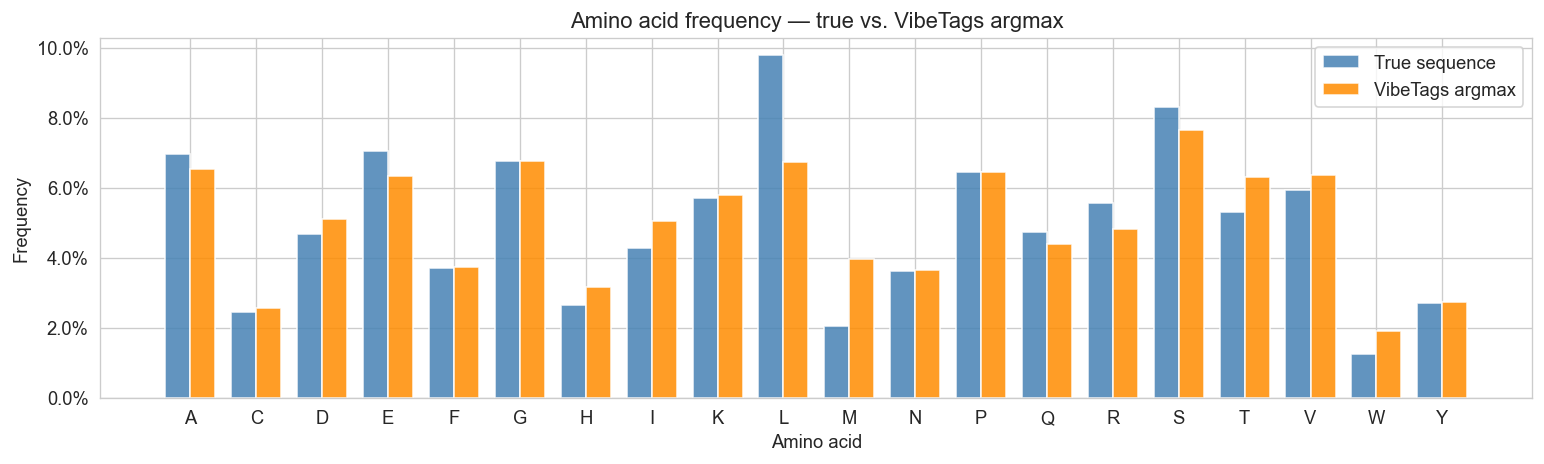

In [4]:
true_counts  = np.zeros(N_AA, dtype=np.int64)
pred_counts  = np.zeros(N_AA, dtype=np.int64)

for seq, out in zip(sequences, outputs):
    for aa in seq:
        true_counts[aa_to_idx[aa]] += 1
    pred_counts += np.bincount(out.argmax(axis=1), minlength=N_AA)

true_freq = true_counts / true_counts.sum()
pred_freq = pred_counts / pred_counts.sum()

x = np.arange(N_AA)
w = 0.38
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w/2, true_freq, width=w, label="True sequence",    color="steelblue",  alpha=0.85)
ax.bar(x + w/2, pred_freq, width=w, label="VibeTags argmax", color="darkorange", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(AA)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set(xlabel="Amino acid", ylabel="Frequency", title="Amino acid frequency — true vs. VibeTags argmax")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Per-Amino-Acid Accuracy

Overall argmax accuracy: 83.076%


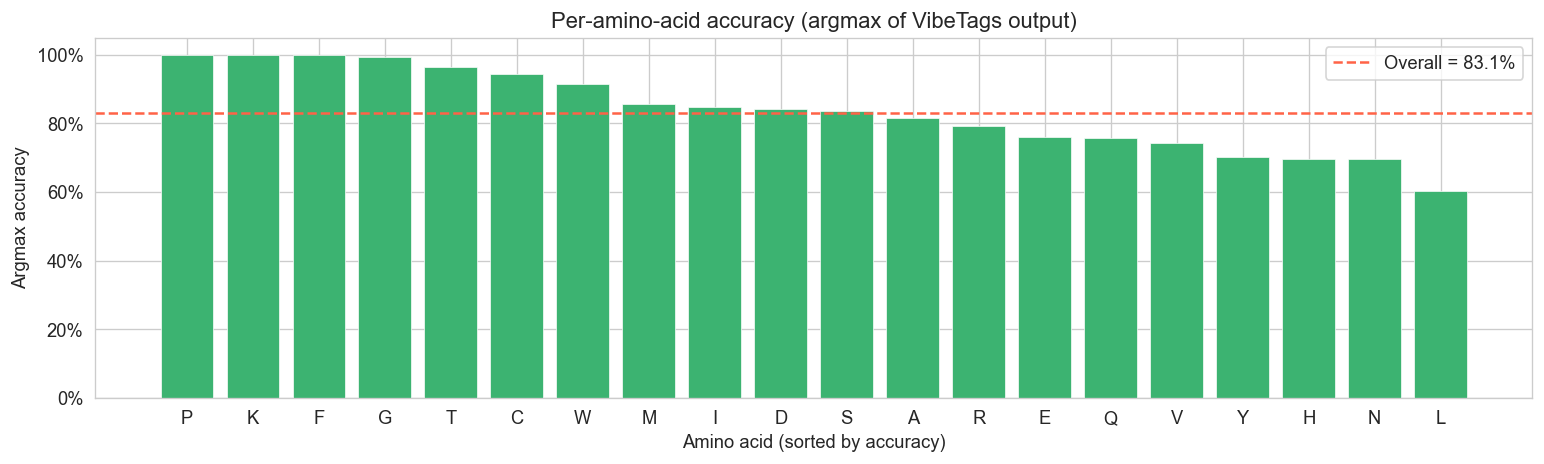

In [5]:
correct = np.zeros(N_AA, dtype=np.int64)
total   = np.zeros(N_AA, dtype=np.int64)

for seq, out in zip(sequences, outputs):
    true_idx = np.array([aa_to_idx[aa] for aa in seq])
    pred_idx = out.argmax(axis=1)
    for i in range(N_AA):
        mask = true_idx == i
        total[i]   += mask.sum()
        correct[i] += (pred_idx[mask] == i).sum()

accuracy = np.where(total > 0, correct / total, np.nan)
overall  = correct.sum() / total.sum()
print(f"Overall argmax accuracy: {overall:.3%}")

order = np.argsort(accuracy)[::-1]
fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(np.arange(N_AA), accuracy[order], color="mediumseagreen", edgecolor="white", linewidth=0.4)
ax.set_xticks(np.arange(N_AA))
ax.set_xticklabels([AA[i] for i in order])
ax.axhline(overall, color="tomato", linestyle="--", label=f"Overall = {overall:.1%}")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set(xlabel="Amino acid (sorted by accuracy)", ylabel="Argmax accuracy",
       title="Per-amino-acid accuracy (argmax of VibeTags output)")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Output Confidence and Entropy

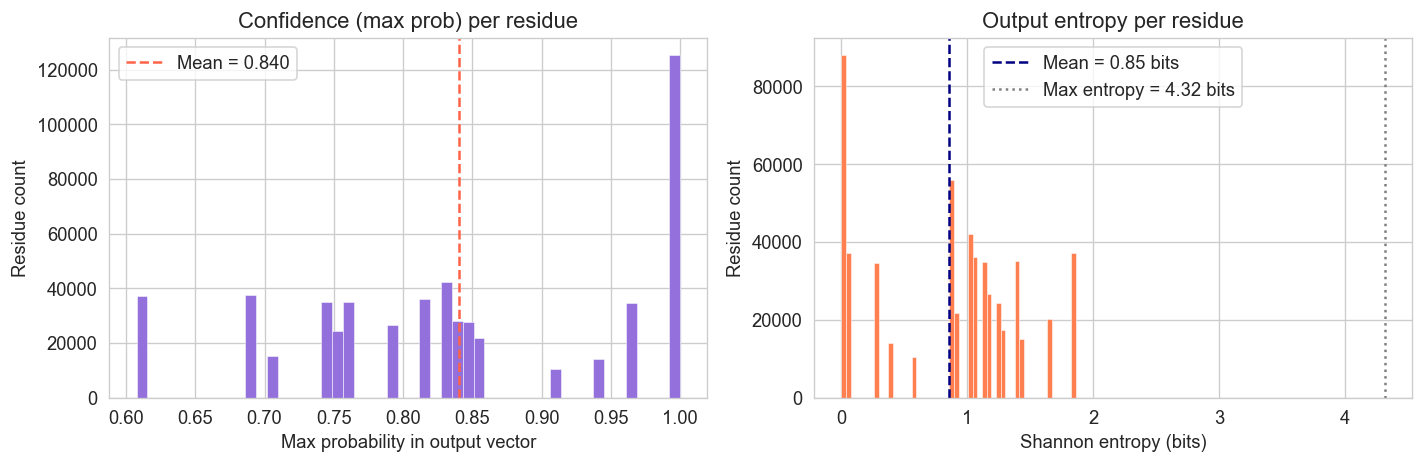

Entropy: mean=0.853, std=0.580, max possible=4.322


In [6]:
all_max_probs = []
all_entropies = []

for out in outputs:
    all_max_probs.append(out.max(axis=1))
    p = np.clip(out, 1e-12, None)
    all_entropies.append(-(p * np.log2(p)).sum(axis=1))

max_probs = np.concatenate(all_max_probs)
entropies = np.concatenate(all_entropies)
max_entropy = np.log2(N_AA)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(max_probs, bins=50, color="mediumpurple", edgecolor="white", linewidth=0.3)
axes[0].set(xlabel="Max probability in output vector", ylabel="Residue count",
            title="Confidence (max prob) per residue")
axes[0].axvline(max_probs.mean(), color="tomato", linestyle="--",
                label=f"Mean = {max_probs.mean():.3f}")
axes[0].legend()

axes[1].hist(entropies, bins=50, color="coral", edgecolor="white", linewidth=0.3)
axes[1].axvline(entropies.mean(), color="navy", linestyle="--",
                label=f"Mean = {entropies.mean():.2f} bits")
axes[1].axvline(max_entropy, color="gray", linestyle=":",
                label=f"Max entropy = {max_entropy:.2f} bits")
axes[1].set(xlabel="Shannon entropy (bits)", ylabel="Residue count",
            title="Output entropy per residue")
axes[1].legend()

fig.tight_layout()
plt.show()
print(f"Entropy: mean={entropies.mean():.3f}, std={entropies.std():.3f}, max possible={max_entropy:.3f}")

## 5. Empirical Confusion Matrix (True vs. VibeTags Argmax)

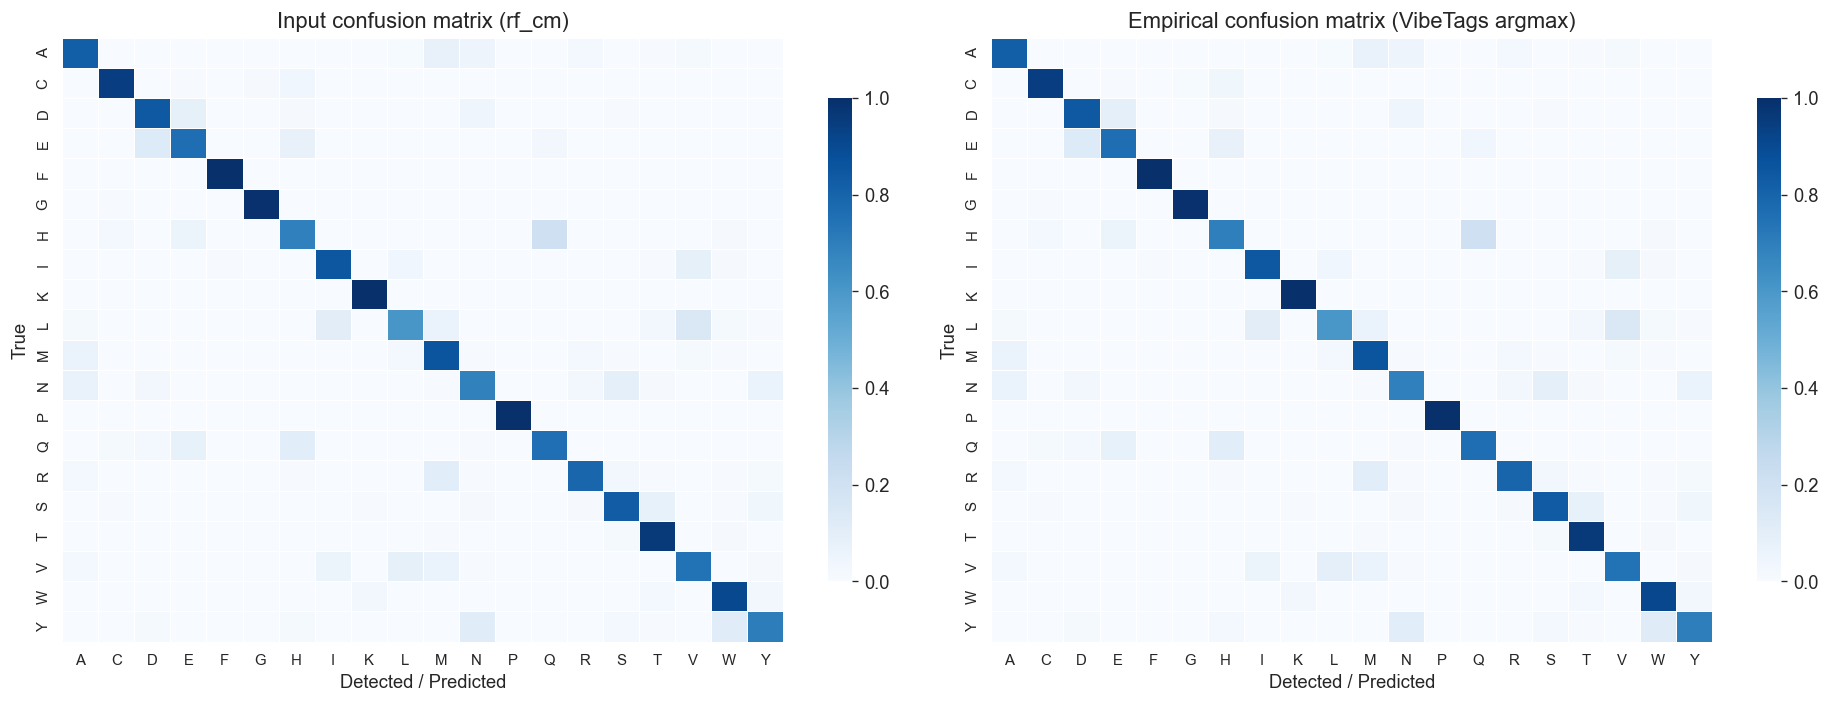

In [7]:
emp_cm = np.zeros((N_AA, N_AA), dtype=np.int64)

for seq, out in zip(sequences, outputs):
    true_idx = np.array([aa_to_idx[aa] for aa in seq])
    pred_idx = out.argmax(axis=1)
    np.add.at(emp_cm, (true_idx, pred_idx), 1)

emp_cm_norm = emp_cm / emp_cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, mat, title in zip(
    axes,
    [cm_frac, emp_cm_norm],
    ["Input confusion matrix (rf_cm)", "Empirical confusion matrix (VibeTags argmax)"],
):
    sns.heatmap(
        mat, ax=ax, xticklabels=AA, yticklabels=AA,
        cmap="Blues", vmin=0, vmax=1,
        linewidths=0.3, linecolor="white",
        annot=False, cbar_kws={"shrink": 0.8},
    )
    ax.set(xlabel="Detected / Predicted", ylabel="True", title=title)
    ax.tick_params(axis="both", labelsize=9)

fig.tight_layout()
plt.show()

## 6. Sample Protein Visualization

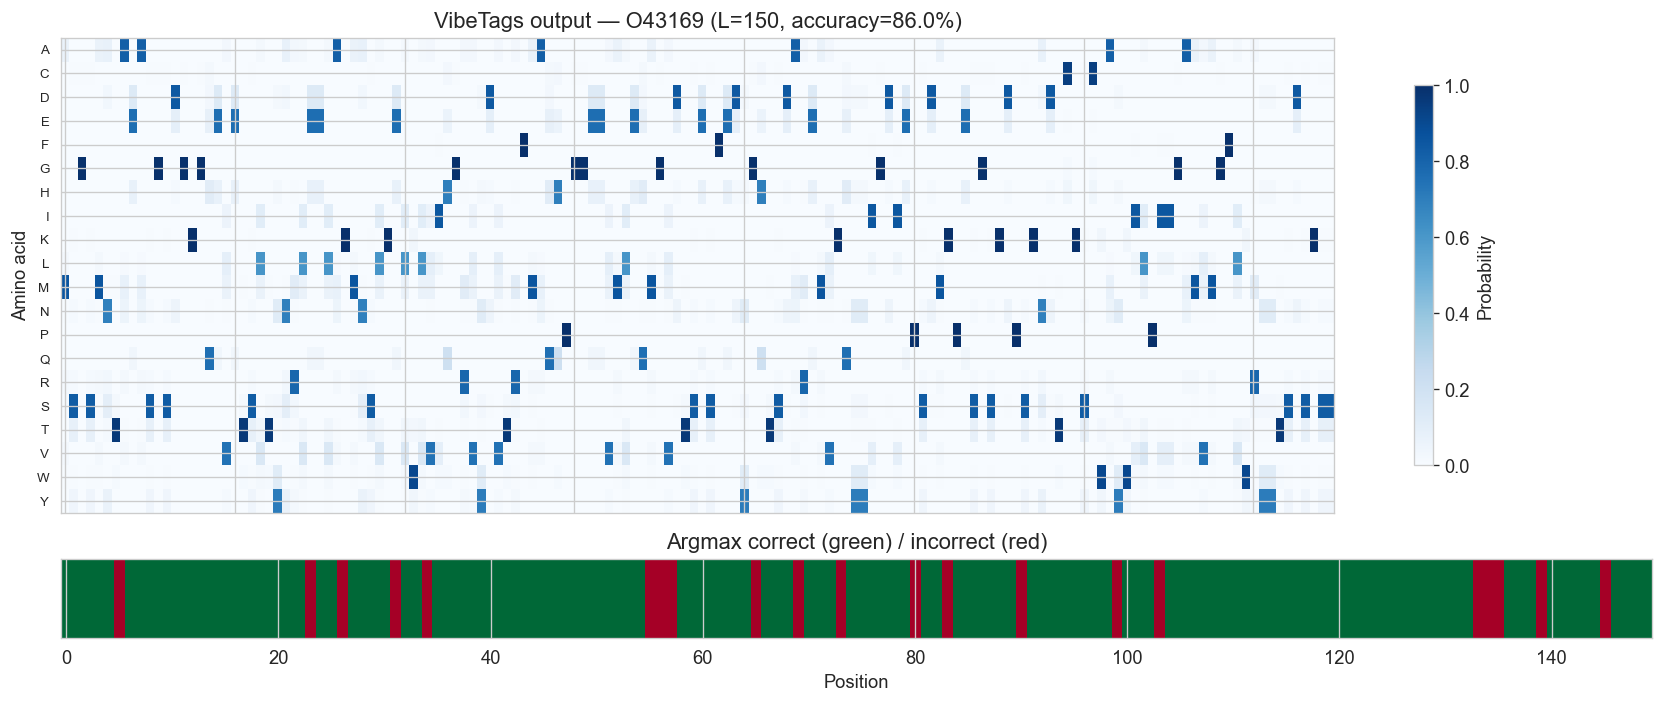

True sequence:      MSGSMATAEASGSDGKGQEVETSVTYYRLEEVAKRNSLKELWLVIHGRVYDVTRFLNEHPGGEEVLLEQAGVDASESFEDVGHSSDAREMLKQYYIGDIHPSDLKPESGSKDPSKNDTCKSCWAYWILPIIGAVLLGFLYRYYTSESKSS
VibeTags argmax:    MSGSMNTAEASGSDGKGQEVETSLTYNRLEELAKMNSLKELWLVIHGRVYDVTRFMAQHPGGEEVMLEQMGVDTSESFEDYGHTSDAREMVKQYYIGDIEPSDMKPESGSKDPSKNDTCKSCWAYWILPIIGAMVMGFLWRYYTSDSKSS


In [8]:
# Pick an interesting protein: not too short, not too long
idx = np.argsort(np.abs(lengths - 150))[0]
seq = sequences[idx]
out = outputs[idx]
pid = protein_ids[idx]
true_idx = np.array([aa_to_idx[aa] for aa in seq])
pred_idx = out.argmax(axis=1)
match = (true_idx == pred_idx)

fig, axes = plt.subplots(2, 1, figsize=(14, 6),
                         gridspec_kw={"height_ratios": [6, 1]}, sharex=True)

im = axes[0].imshow(out.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[0].set_yticks(np.arange(N_AA))
axes[0].set_yticklabels(AA, fontsize=8)
axes[0].set(ylabel="Amino acid",
            title=f"VibeTags output — {pid} (L={len(seq)}, accuracy={match.mean():.1%})")
plt.colorbar(im, ax=axes[0], label="Probability", shrink=0.8)

axes[1].imshow(
    match.reshape(1, -1), aspect="auto",
    cmap="RdYlGn", vmin=0, vmax=1,
)
axes[1].set_yticks([])
axes[1].set(xlabel="Position", title="Argmax correct (green) / incorrect (red)")

fig.tight_layout()
plt.show()

print(f"True sequence:      {seq}")
print(f"VibeTags argmax:    {''.join(AA[i] for i in pred_idx)}")

## 7. Entropy by Amino Acid — Where is VibeTags Most Uncertain?

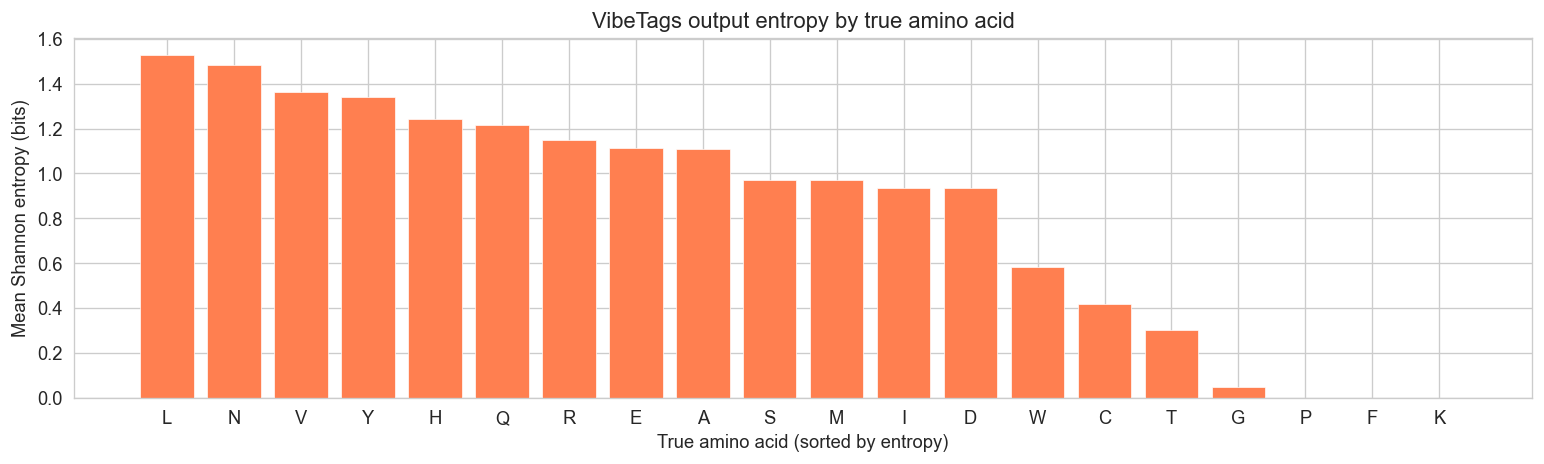

In [9]:
entropy_by_aa = {aa: [] for aa in AA}

for seq, out in zip(sequences, outputs):
    p = np.clip(out, 1e-12, None)
    ent = -(p * np.log2(p)).sum(axis=1)
    for pos, aa in enumerate(seq):
        entropy_by_aa[aa].append(ent[pos])

mean_ent = np.array([np.mean(entropy_by_aa[aa]) for aa in AA])
order = np.argsort(mean_ent)[::-1]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(np.arange(N_AA), mean_ent[order], color="coral", edgecolor="white", linewidth=0.4)
ax.set_xticks(np.arange(N_AA))
ax.set_xticklabels([AA[i] for i in order])
ax.set(xlabel="True amino acid (sorted by entropy)", ylabel="Mean Shannon entropy (bits)",
       title="VibeTags output entropy by true amino acid")
fig.tight_layout()
plt.show()

## 8. Random Protein — Full Probability Distribution

Pick a random protein and inspect the raw VibeTags probability distribution at every position.
The top panel shows the full L×20 heatmap; the lower grid drills into individual positions so the
per-residue distributions are easy to read.

Protein : Q15084  (length 440, argmax accuracy 84.5%)
True    : MALLVLGLVSCTFFLAVNGLYSSSDDVIELTPSNFNREVIQSDSLWLVEFYAPWCGHCQRLTPEWKKAATALKDVVKVGAVDADKHHSLGGQYGVQGFPTIKIFGSNKNRPEDYQGGRTGEAIVDAALSALRQLVKDRLGGRSGGYSSGKQGRSDSSSKKDVIELTDDSFDKNVLDSEDVWMVEFYAPWCGHCKNLEPEWAAAASEVKEQTKGKVKLAAVDATVNQVLASRYGIRGFPTIKIFQKGESPVDYDGGRTRSDIVSRALDLFSDNAPPPELLEIINEDIAKRTCEEHQLCVVAVLPHILDTGAAGRNSYLEVLLKLADKYKKKMWGWLWTEAGAQSELETALGIGGFGYPAMAAINARKMKFALLKGSFSEQGINEFLRELSFGRGSTAPVGGGAFPTIVEREPWDGRDGELPVEDDIDLSDVELDDLGKDEL
Argmax  : MALLVVGLVSCTFFLAVNGLNSTTEDVIDLTPSNFNRHVLQSDSLWLLEFYAPWCGHCQRLTPEWKKMATAMKDMMKVGAVDADKHQYVGGQYGVQGFPTIKVFGSNKNRPEDNHGGRTGDAILDLAISALRQLVKDRLGGRNGGYSSGKQGRSDSSSKKDVIELTDDSFDKNVLESEDYWMIEFYTPTCGHCKNLDPEWAAMANDVKEHTKGKYKLAAVDRTINQVLASRYGIRGFPTIKIFCKGESPVDWDGGRTRSDIVSAMLNIFSENAPPPEALEIINEDIAKRTCEHWQLCVVALLPHILDTGVAGRNSYLHMILKLVDKYKKKMWGWLWTEAGAEWELETALGVGGFGYPAMAAINARKAKFALLKGSFSHQGINEFVRELSFGRGSTAPMGGGAFPTIMHREPWDGREGDLPVDDDIDLSDVEINDVGKDEL


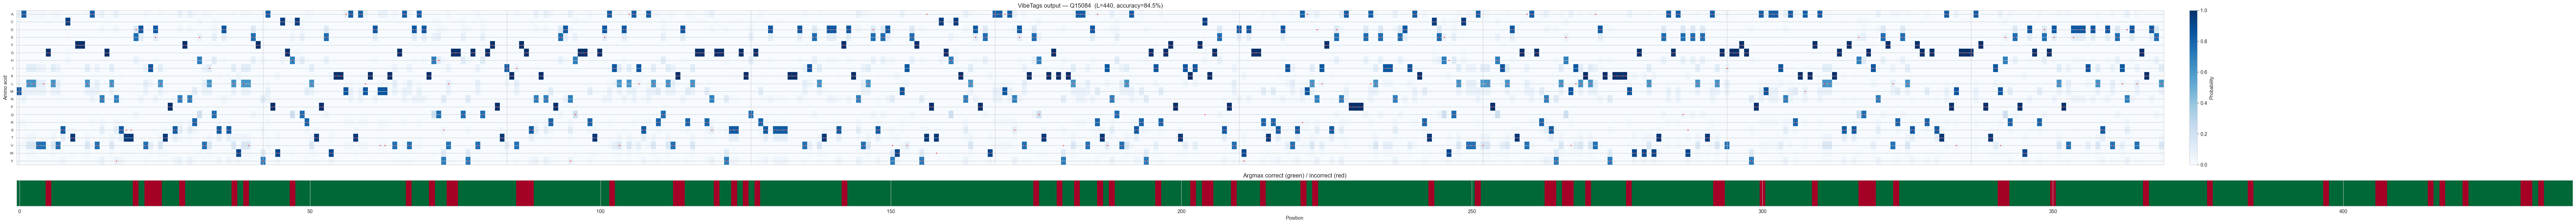

/var/folders/y_/f9145rc93ts8_6nfpj2h1sph0000gn/T/ipykernel_47540/1972444581.py:71: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig2.tight_layout()
/var/folders/y_/f9145rc93ts8_6nfpj2h1sph0000gn/T/ipykernel_47540/1972444581.py:71: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig2.tight_layout()


/Users/jonathanzhao/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jonathanzhao/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


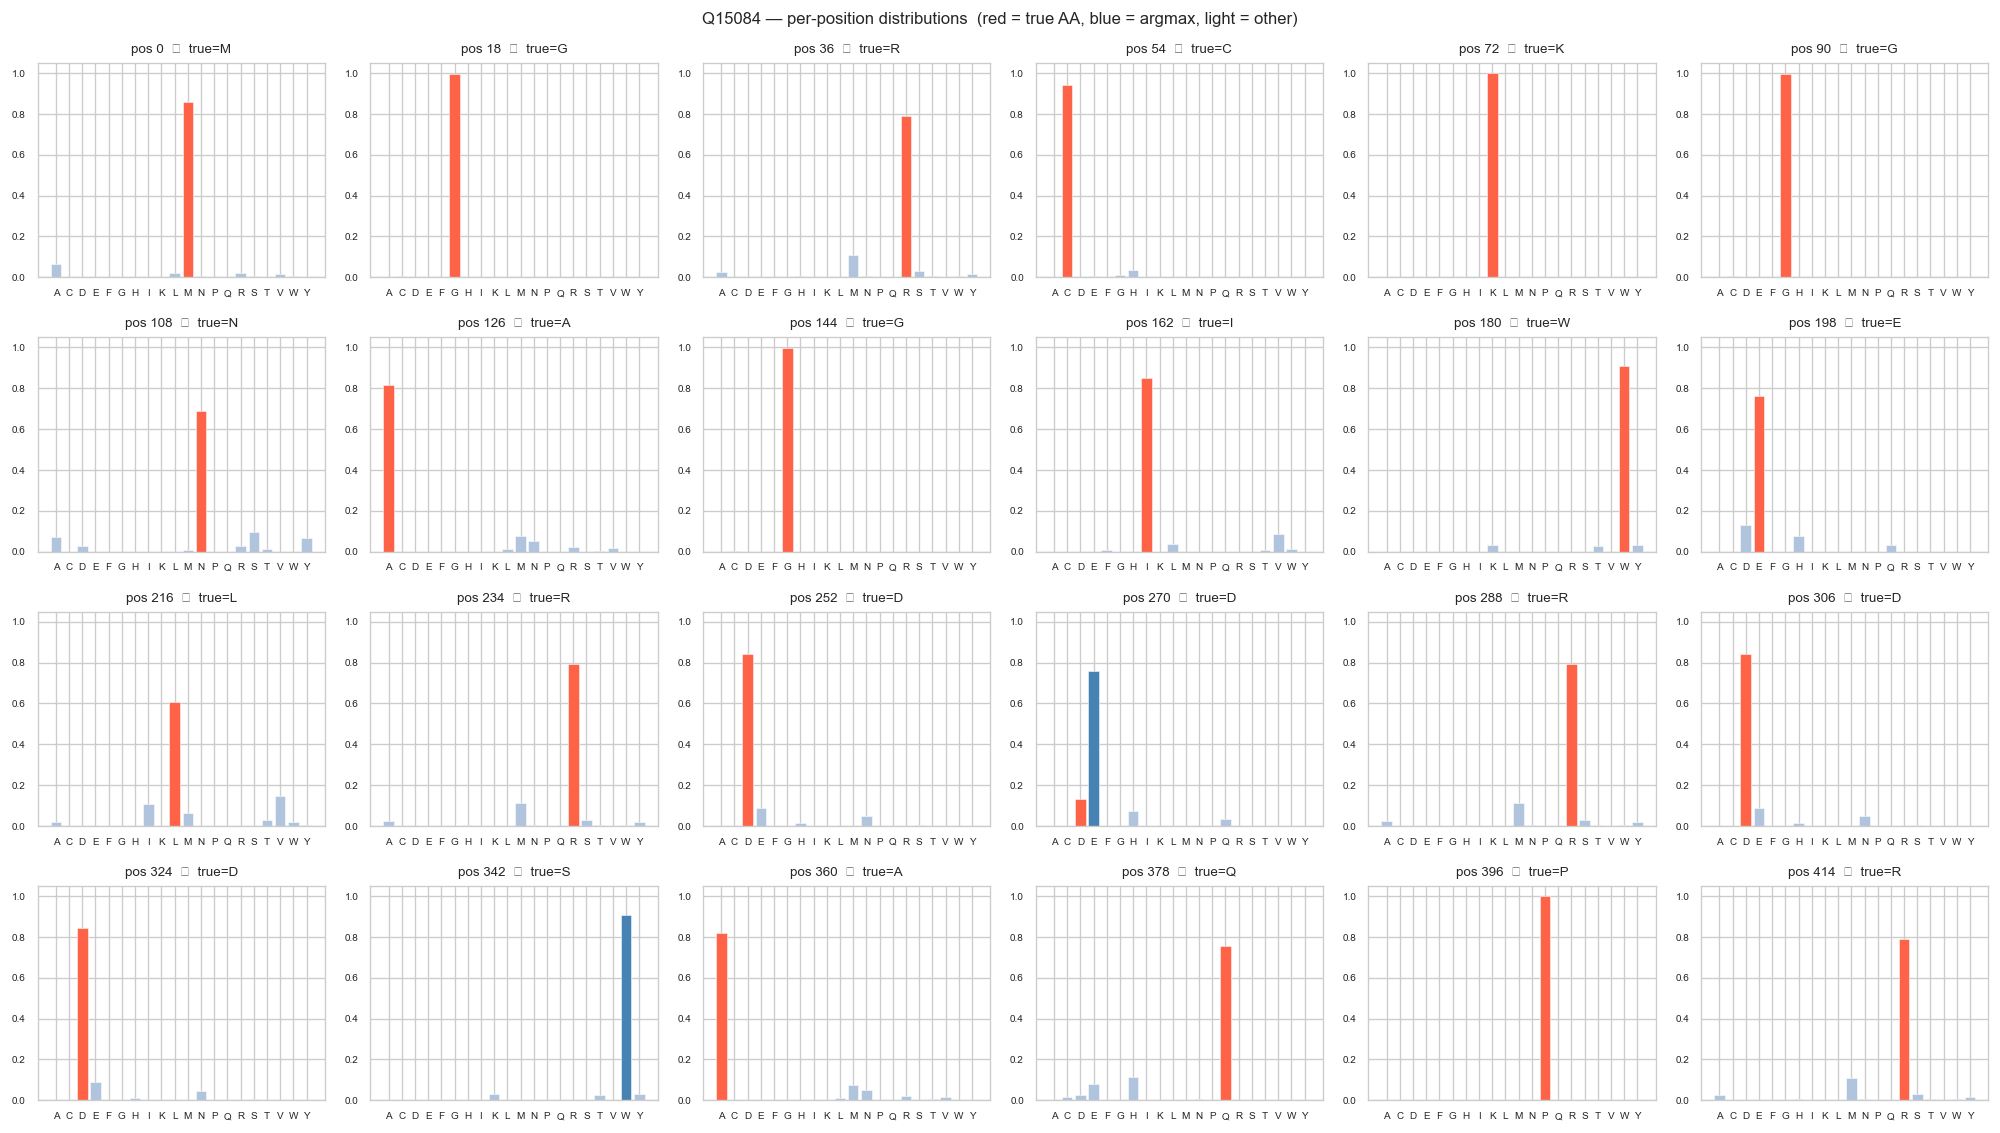

In [10]:
rng_vis = np.random.default_rng(seed=None)   # change seed to fix a particular protein
vis_idx = rng_vis.integers(len(sequences))
vis_seq = sequences[vis_idx]
vis_out = outputs[vis_idx]
vis_pid = protein_ids[vis_idx]
vis_true = np.array([aa_to_idx[aa] for aa in vis_seq])
vis_pred = vis_out.argmax(axis=1)
vis_match = vis_true == vis_pred
L = len(vis_seq)

print(f"Protein : {vis_pid}  (length {L}, argmax accuracy {vis_match.mean():.1%})")
print(f"True    : {vis_seq}")
print(f"Argmax  : {''.join(AA[i] for i in vis_pred)}")

# ── Panel 1: full L×20 heatmap ──────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 1, figsize=(max(14, L * 0.18), 7),
    gridspec_kw={"height_ratios": [6, 1]}, sharex=True,
)

im = axes[0].imshow(vis_out.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[0].set_yticks(np.arange(N_AA))
axes[0].set_yticklabels(AA, fontsize=8)
axes[0].set(ylabel="Amino acid",
            title=f"VibeTags output — {vis_pid}  (L={L}, accuracy={vis_match.mean():.1%})")
plt.colorbar(im, ax=axes[0], label="Probability", pad=0.01)

# Mark true amino acid at each position with a red dot
for pos, true_i in enumerate(vis_true):
    axes[0].plot(pos, true_i, "r.", markersize=3, alpha=0.7)

axes[1].imshow(vis_match.reshape(1, -1), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
axes[1].set_yticks([])
axes[1].set(xlabel="Position", title="Argmax correct (green) / incorrect (red)")

fig.tight_layout()
plt.show()

# ── Panel 2: per-position bar charts for a sample of positions ───────────────
n_cols = 6
step = max(1, L // (n_cols * 4))          # sample ~4 rows worth of positions
sample_pos = np.arange(0, L, step)[:n_cols * 4]
n_rows = int(np.ceil(len(sample_pos) / n_cols))

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.8, n_rows * 2.4))
axes2 = np.array(axes2).reshape(n_rows, n_cols)

for k, pos in enumerate(sample_pos):
    ax = axes2[k // n_cols, k % n_cols]
    probs = vis_out[pos]
    colors = ["tomato" if i == vis_true[pos] else
              ("steelblue" if i == vis_pred[pos] else "lightsteelblue")
              for i in range(N_AA)]
    ax.bar(np.arange(N_AA), probs, color=colors, edgecolor="white", linewidth=0.3)
    ax.set_xticks(np.arange(N_AA))
    ax.set_xticklabels(AA, fontsize=6)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.tick_params(axis="y", labelsize=6)
    correct_marker = "✓" if vis_match[pos] else "✗"
    ax.set_title(f"pos {pos}  {correct_marker}  true={AA[vis_true[pos]]}", fontsize=8)

for k in range(len(sample_pos), n_rows * n_cols):
    axes2[k // n_cols, k % n_cols].set_visible(False)

fig2.suptitle(
    f"{vis_pid} — per-position distributions  "
    f"(red = true AA, blue = argmax, light = other)",
    fontsize=10,
)
fig2.tight_layout()
plt.show()